In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import flax
import flax.linen as nn
import optax
from typing import Tuple, Callable, Any, Dict, Optional
import numpy.typing as npt
import copy
import pathlib
import matplotlib.pyplot as plt
import time

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
jax.devices()

In [ ]:
class BestIterKeeper:
    """Store the values of a bunch of quantities from the best iteration.

    "Best" is defined in the sense of lowest energy.

    Args:
        Hamiltonian: An array containing the Hamiltonian matrix.
        N: The number of spins in the chain.
        baseline: A lower bound for the V score. If the V score of the best
            iteration falls under this threshold, the process will be stopped
            early.
        filename: Either None or a file to write the best state to.
    """

    def __init__(
        self,
        Hamiltonian: npt.ArrayLike,
        N: int,
        baseline: float,
        filename: Optional[pathlib.Path] = None,
    ):
        self.Hamiltonian = Hamiltonian
        self.N = N
        self.baseline = baseline
        self.filename = filename
        self.vscore = np.inf
        self.best_energy = np.inf
        self.best_state = None

    def update(self, step, log_data, driver):
        """Update the stored quantities if necessary.

        This function is intended to act as a callback for NetKet. Please refer
        to its API documentation for a detailed explanation.
        """
        vstate = driver.state
        energystep = np.real(vstate.expect(self.Hamiltonian).mean)
        var = np.real(getattr(log_data[driver._loss_name], "variance"))
        mean = np.real(getattr(log_data[driver._loss_name], "mean"))
        varstep = self.N * var / mean**2

        if self.best_energy > energystep:
            self.best_energy = energystep
            self.best_state = copy.copy(driver.state)
            self.best_state.parameters = flax.core.copy(driver.state.parameters)
            self.vscore = varstep

            if self.filename != None:
                with open(self.filename, "wb") as file:
                    file.write(flax.serialization.to_bytes(driver.state))

        return self.vscore > self.baseline

In [ ]:
from VA_project.model.model import OxalateJKGamma
from VA_project.engine.runners import Runner
import netket as nk

settings={
    
    'size': (4,4), #Lattice size
    'alpha':2.5,

    'NN_arch': {

        'MLP': {

            'rng' : jax.random.PRNGKey(0),
            'layers' : ['dense', 'activation', 'dense'],
            'dimensions' : [128, 128],
            'activation' : [nn.sigmoid],
            'dropout' : [],

        }

    },
    'optimizer': {
        'adam': {
            'learning_rate': 0.01
        },
        'Sgd': {
            'learning_rate': 0.01
        },
        'AdaGrad': {
            'learning_rate': 0.01
        },
    },   

    'sampler': {
        'type': 'MetropolisLocal',
        'n_samples': 1008,
        
    },
}




In [ ]:
class MLP(nn.Module):
    """A simple multi-layer perceptron."""
    
    param_dtype : Any = jnp.complex64
    hidden_dims: int | Tuple[int, ...] = None
    activation: Callable | Tuple[Callable, ...] = None

    def setup(self):
        assert self.hidden_dims is not None, "Hidden_dims must be provided."

        if self.activation is None:
            self.activation = tuple([0] * len(self.hidden_dims))
        else:
            if len(self.hidden_dims) != len(self.activation):
                raise ValueError("The number of hidden dimensions must match the number of activation functions,"
                                 f" but got {len(self.hidden_dims)} and {len(self.activation)} respectively.")
        
    @nn.compact
    def __call__(self, x):
        
        for hi, act in zip(self.hidden_dims, self.activation):
            x = nn.Dense(hi, param_dtype=self.param_dtype)(x)
            if act:
                x = act(x)

        return x.squeeze(-1)
    


In [ ]:
strength = 0.2
theta = 9.0
phi = 72.

diag_shift= 0.001
n_iter=1000


act_dict={
    'sigmoid': nn.sigmoid,
    'tanh': nn.tanh,
    'softmax': nn.softmax,
    'gelu': nn.gelu,}

opt_name_dict={
    'Sgd': nk.optimizer.Sgd,
    'adam': nk.optimizer.Adam,
    'AdaGrad': nk.optimizer.AdaGrad,} 

opt_name_list = ['Sgd', 'adam', 'AdaGrad']
learning_rate_list = [0.1, 0.01, 0.001]

dimensions_list = [
    (16,16,1),
    (32,32,1),
    (64,64,1),
    (16,32,64,64,32,16,1),
]
activation_list = [
    [('softmax',0,0),(0,'softmax',0),('tanh',0,0),(0,'tanh',0),('gelu',0,0),(0,'gelu',0)],
    [('softmax',0,0),(0,'softmax',0),('tanh',0,0),(0,'tanh',0),('gelu',0,0),(0,'gelu',0)],
    [('softmax',0,0),(0,'softmax',0),('tanh',0,0),(0,'tanh',0),('gelu',0,0),(0,'gelu',0)],
    [('softmax',0,0,'softmax',0,'softmax',0),('tanh',0,0,'tanh',0,'tanh',0),('gelu',0,0,'gelu',0,'gelu',0), ('gelu',0,0,'sigmoide',0,'tanh',0)]
]


d=0 ; a=0 

for d, dimensions in enumerate(dimensions_list): 
    
    for a, activation_name in enumerate(activation_list[d]):

        activation = tuple([act_dict[act] if act != 0 else 0 for act in activation_name])

        for opt_name in opt_name_list:

            for learning_rate in learning_rate_list:

                print(f"dimensions: {dimensions} \nactivation: {activation_name} \nopt_name: {opt_name} \nlearning_rate: {learning_rate}")

                time_in = time.time()
                
                # Initialize the model
                model = MLP(
                    param_dtype=jnp.complex64,
                    hidden_dims=dimensions,
                    activation=activation,
                    )
                # ...with rng keys 
                rng= jax.random.PRNGKey(0)
                key1, key2 = jax.random.split(rng)
                keys = {'params': key1, 'dropout': key2}

                params = model.init(keys['params'], jnp.ones((4*4), dtype=jnp.complex64)) 
                output=model.apply(params, jnp.ones((4*4), dtype=jnp.complex64))

                hi = nk.hilbert.Spin(s=0.5, N = int(np.prod(settings['size'])))

                sampler = nk.sampler.MetropolisLocal(hi, dtype=complex)
                #print(sampler.sample_next(NN_arch, model_params))

                optimizer = opt_name_dict[opt_name](learning_rate=learning_rate)

                vstate = nk.vqs.MCState(sampler, model, n_samples = settings['sampler']['n_samples'])
                is_holo = nk.utils.is_probably_holomorphic(vstate._apply_fun, vstate.parameters, vstate.samples, vstate.model_state)

                SR= nk.optimizer.SR(diag_shift = diag_shift, holomorphic = True)

                # Create the Hamiltonian
                oxa=OxalateJKGamma(settings['size'], 
                                [strength, theta, phi],
                                    bc='periodic', order='default_2')
                H = Runner(oxa.cm).build_hamiltonian()

                gs = nk.VMC(
                    hamiltonian=H,
                    optimizer=optimizer,
                    preconditioner=SR,
                    variational_state=vstate)
                log = nk.logging.RuntimeLog()
                keeper= BestIterKeeper(H, np.prod(settings['size']), baseline = 1e-8,
                    #filename=pathlib.Path("best_state.nk"),
                )
                gs.run(n_iter=n_iter, out=log, callback= [keeper.update])
                time_out = time.time()
                time_exe= time_out - time_in

                # Extract some results
                E_hist = np.array(log['Energy']['Mean']).real
                dev_E_hist = np.array(log['Energy']['Sigma']).real
                E_gr = Runner(oxa.cm).exact_energy_lanczos()

                # Calculate the variance score
                var= np.array(log['Energy']['Variance']).real
                vscore = int(np.prod(settings['size']))*var//(E_hist**2)
                error=np.abs(E_hist-E_gr)/np.abs(E_gr)

                print(f"E_hist: {len(E_hist)}")
                print(f"dev_E_hist: {len(dev_E_hist)}")
                print(f"vscore: {len(vscore)}")
                print(f"error: {len(error)}")

                # Plotting

                set_dim=[f"D({dim})" for dim in dimensions]
                set_act=[f"A({act})" for act in activation_name]
                setup='||'
                for i in range(len(dimensions)):
                    setup+=f" {set_dim[i]} |"
                    setup+=f" {set_act[i]} |" if '0' not in set_act[i] else ''
                    
                setup+="|"
                setup_sim = f"opt: {opt_name} \nl_rate: {learning_rate} \ntime_exe: {time_exe}"

                fig, ax = plt.subplots(3,1,figsize=(8, 18))
                ax[0].set_title(f"Convergence 4x4 theta=9 phi=72")
                ax[0].errorbar(range(len(E_hist)), E_hist, yerr=dev_E_hist, fmt='none', ecolor='r', label='E_stdev')
                ax[0].plot(E_hist, color='blue', label='E') 
                ax[0].hlines(E_gr,0,n_iter, color='green', label='ED Energy')
                ax[0].text(0.45, 0.93, setup, transform=ax[0].transAxes, fontsize=12, color='k', ha='center', va='center',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
                ax[0].text(0.9, 0.75, setup_sim, transform=ax[0].transAxes, fontsize=10, color='k', ha='center', va='center',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

                ax[0].legend()
                ax[0].set_xlabel('Iteration')
                ax[0].set_ylabel('Energy', fontsize=12)
                ax[0].grid()

                ax[1].plot(error, color='red', label='E')
                ax[1].set_yscale('log')
                ax[1].legend()
                ax[1].set_xlabel('Iteration')
                ax[1].set_ylabel('Error', fontsize=12)
                ax[1].grid()


                ax[2].plot(vscore, color='purple', label='Vscore')
                ax[2].set_yscale('log')
                ax[2].legend()
                ax[2].set_xlabel('Iteration')
                ax[2].set_ylabel('Vscore', fontsize=12)
                ax[2].grid()
                plt.tight_layout()
                plt.savefig(f"Figures/First_sim/4x4_theta9_phi72_d{d}_a{a}_{opt_name}_lr_{learning_rate}.jpeg", dpi=600)

In [56]:
opt_name = 'AdaGrad'
learning_rate_list = [0.1]

dimensions = (32,32,1)
activation= ('softmax',0,0)

act_dict={
    'sigmoid': nn.sigmoid,
    'tanh': nn.tanh,
    'softmax': nn.softmax,
    'gelu': nn.gelu
}

opt_name_dict={
    'Sgd': nk.optimizer.Sgd,
    'adam': nk.optimizer.Adam,
    'AdaGrad': nk.optimizer.AdaGrad
} 


activation = tuple([act_dict[act] if act != 0 else 0 for act in activation])

In [57]:
# Initialize the model
model = MLP(
    param_dtype=jnp.complex64,
    hidden_dims=dimensions,
    activation=activation,
    )
# ...with rng keys 
rng= jax.random.PRNGKey(0)
key1, key2 = jax.random.split(rng)
keys = {'params': key1, 'dropout': key2}

params = model.init(keys['params'], jnp.ones((4*4), dtype=jnp.complex64)) 
output=model.apply(params, jnp.ones((4*4), dtype=jnp.complex64))

hi = nk.hilbert.Spin(s=0.5, N = int(np.prod(settings['size'])))

sampler = nk.sampler.MetropolisHamiltonian(hi, hamiltonian= H, dtype=complex)
#print(sampler.sample_next(NN_arch, model_params))

optimizer = opt_name_dict[opt_name](learning_rate=learning_rate)

vstate = nk.vqs.MCState(sampler, model, n_samples = settings['sampler']['n_samples'])
is_holo = nk.utils.is_probably_holomorphic(vstate._apply_fun, vstate.parameters, vstate.samples, vstate.model_state)

SR= nk.optimizer.SR(diag_shift = diag_shift, holomorphic = True)

# Create the Hamiltonian
oxa=OxalateJKGamma(settings['size'], 
                [strength, theta, phi],
                    bc='periodic', order='default_2')
H = Runner(oxa.cm).build_hamiltonian()

gs = nk.VMC(
    hamiltonian=H,
    optimizer=optimizer,
    preconditioner=SR,
    variational_state=vstate)
log = nk.logging.RuntimeLog()
keeper= BestIterKeeper(H, np.prod(settings['size']), baseline = 1e-8,
    #filename=pathlib.Path("best_state.nk"),
)
gs.run(n_iter=n_iter, out=log, callback= [keeper.update])

  0%|          | 0/1000 [00:00<?, ?it/s]

(RuntimeLog():
  keys = ['acceptance', 'Energy'],)

In [82]:
keeper.best_energy

Array(-0.91289122, dtype=float64)

In [79]:
activ={
    'sigmoid': nn.sigmoid,
    'tanh': nn.tanh,
    'softmax': nn.softmax,
    'gelu': nn.gelu,
    'relu': nn.relu,
    'swish': nn.swish,
    'elu': nn.elu,
    'leaky_relu': nn.leaky_relu,
    'selu': nn.selu,
    'softplus': nn.softplus,
    'log_sigmoid': nn.log_sigmoid,
    'log_softmax': nn.log_softmax,
    'soft_sign': nn.soft_sign,
    'standardize': nn.standardize,
    'hard_sigmoid': nn.hard_sigmoid,
    'hard_tanh': nn.hard_tanh,
    'hard_swish': nn.hard_swish,
}

In [80]:
nn.glu(jnp.ones((4*4), dtype=jnp.complex64), 0)

Array([0.73105854+0.j, 0.73105854+0.j, 0.73105854+0.j, 0.73105854+0.j,
       0.73105854+0.j, 0.73105854+0.j, 0.73105854+0.j, 0.73105854+0.j],      dtype=complex64)

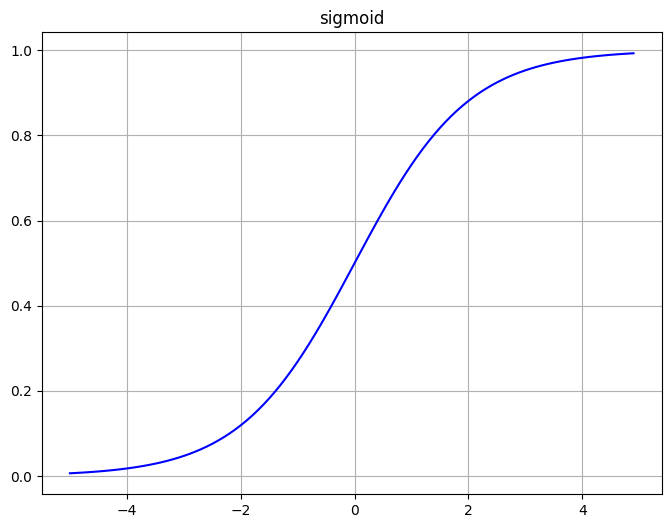

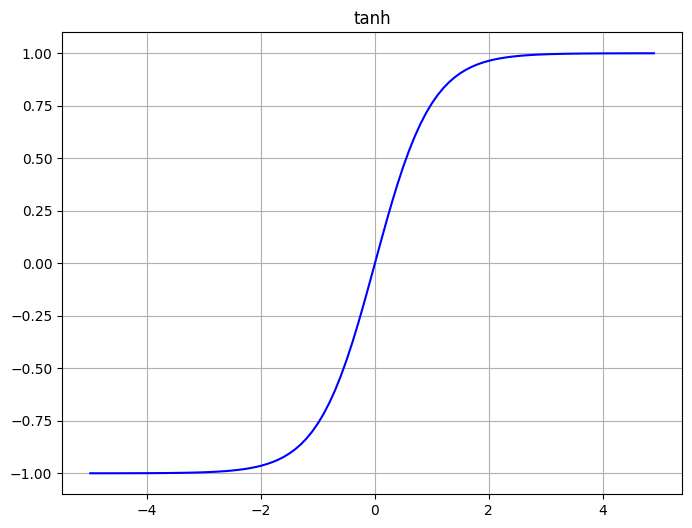

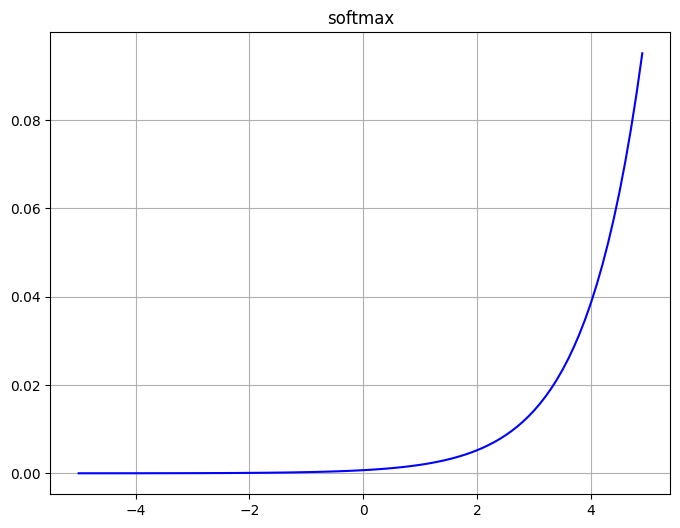

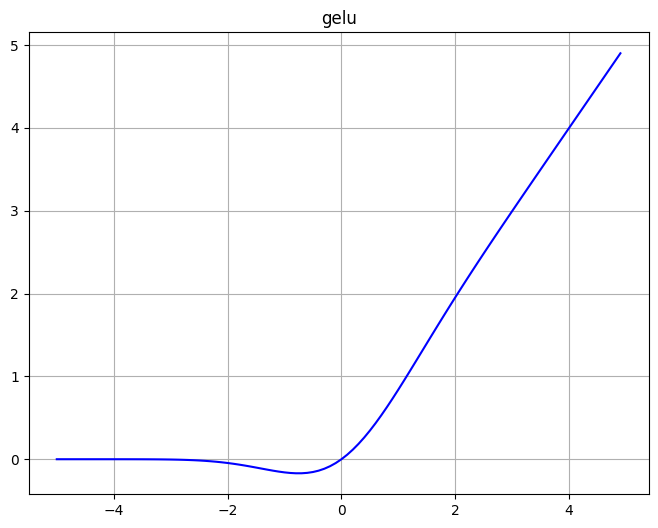

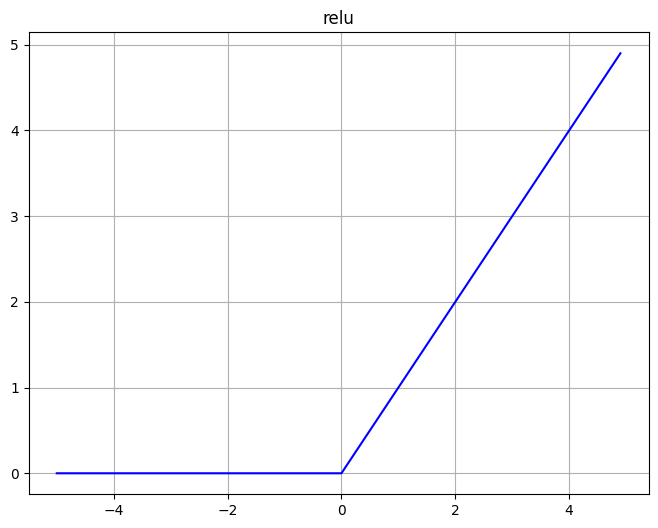

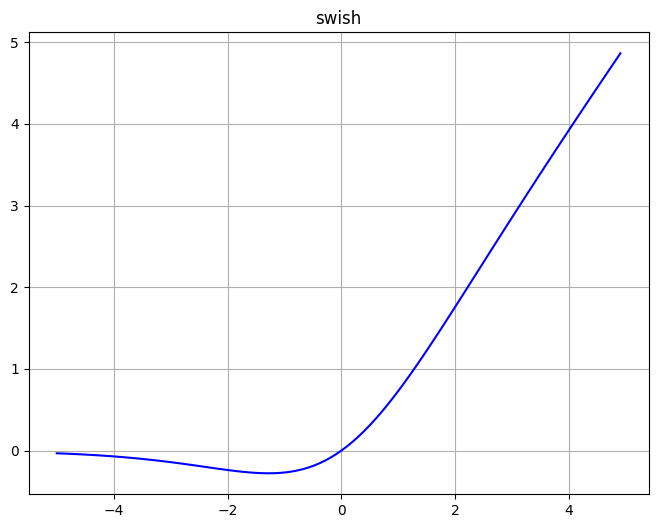

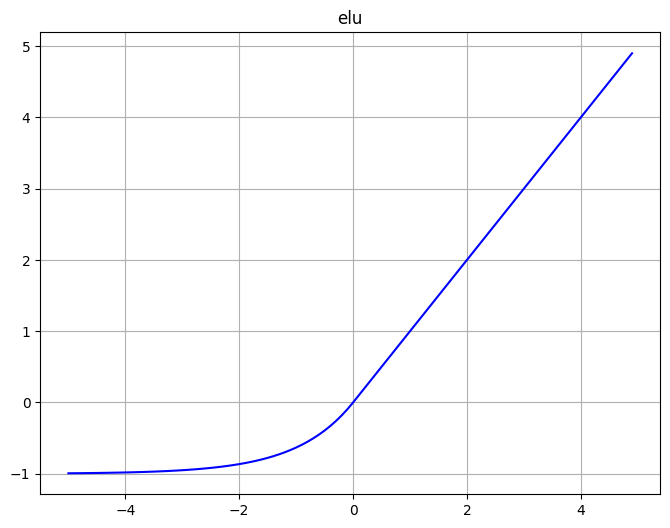

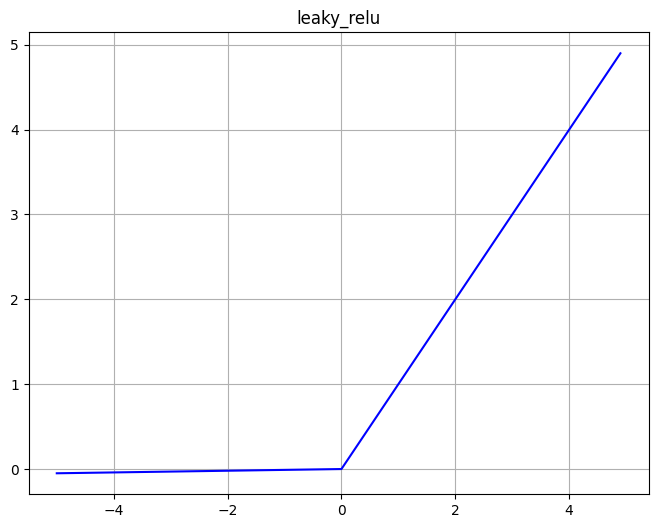

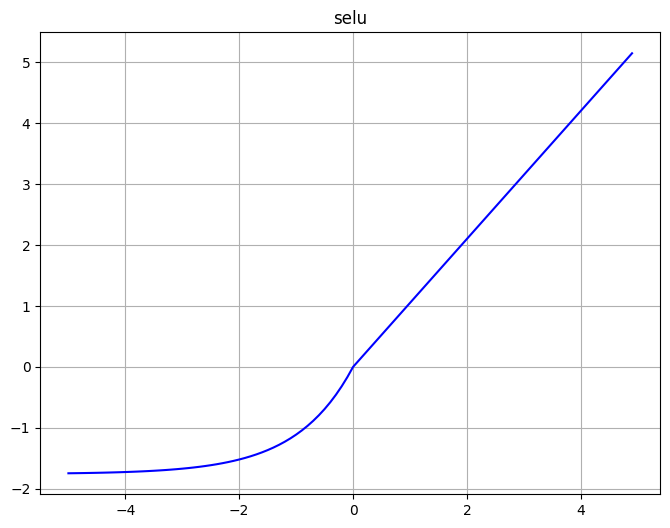

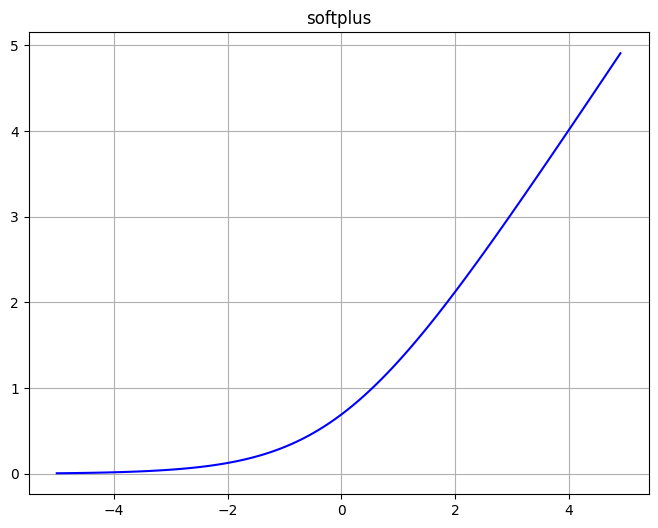

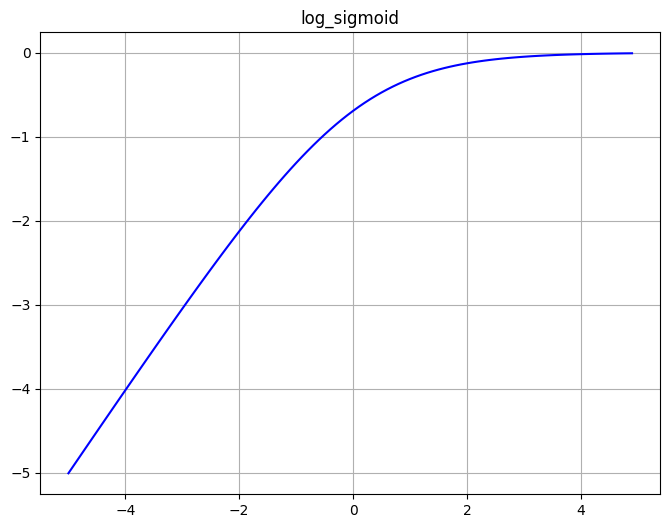

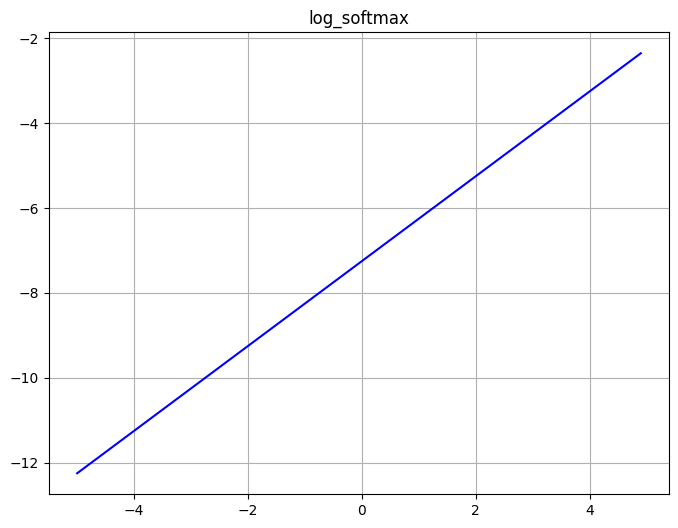

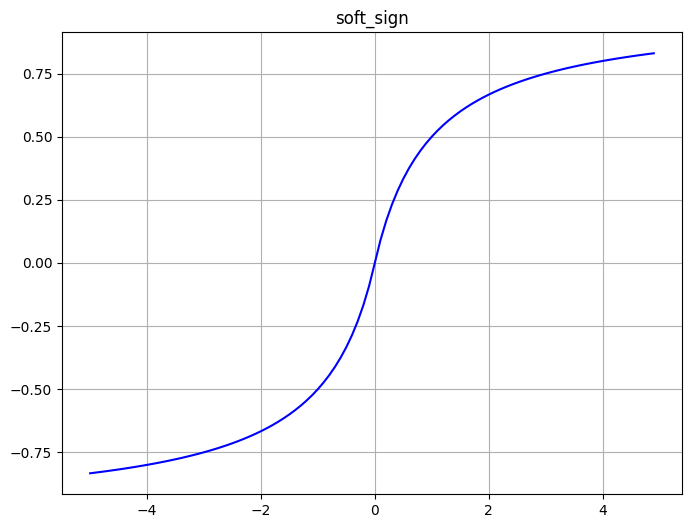

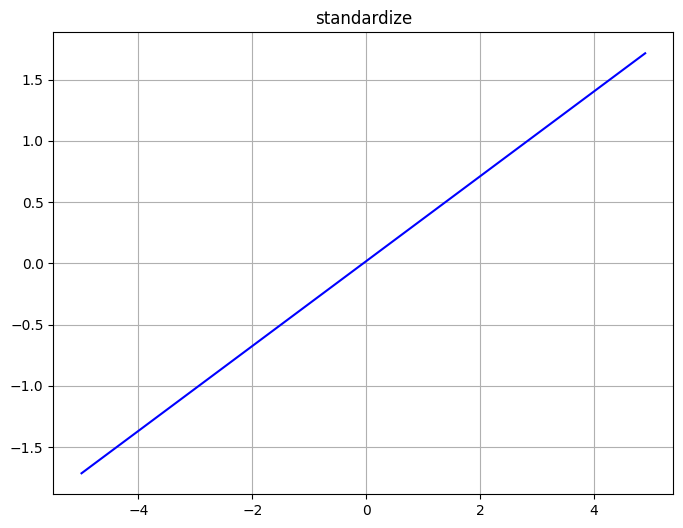

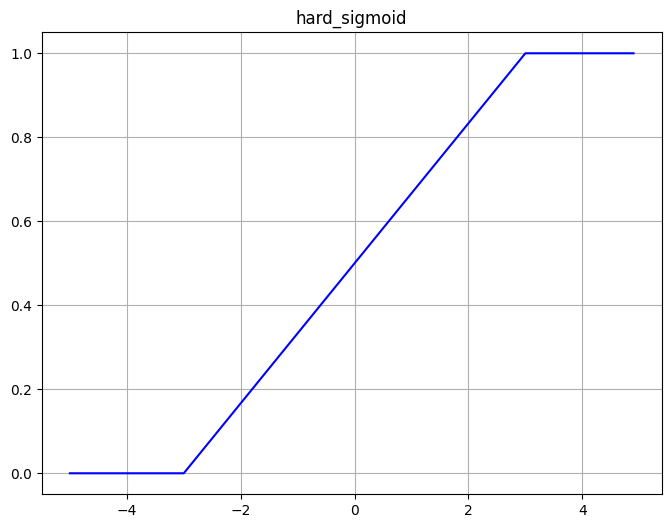

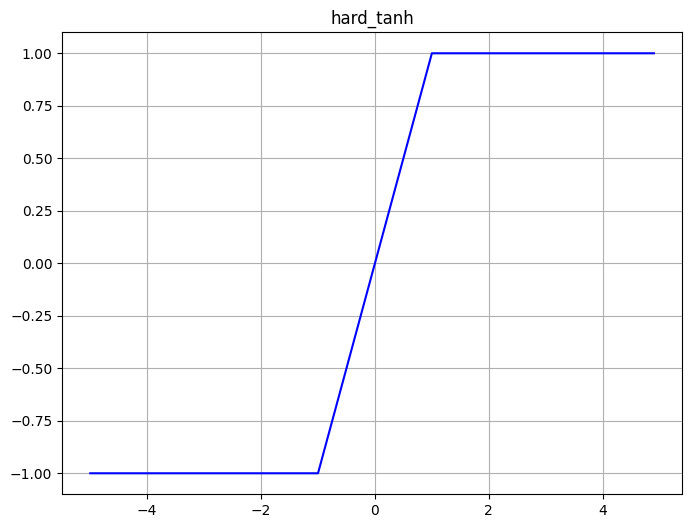

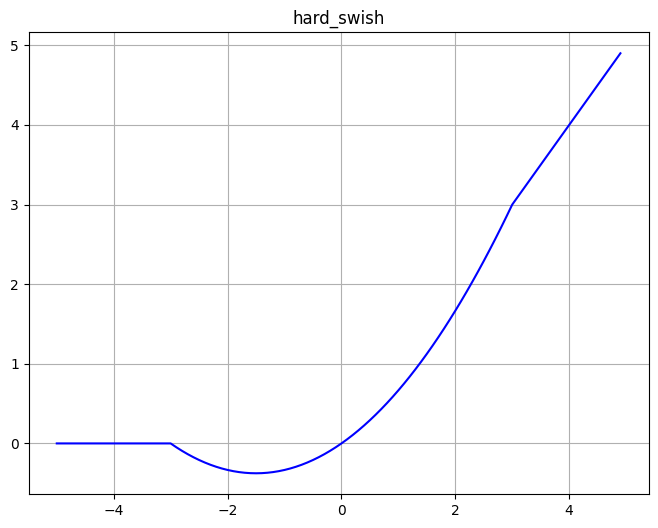

In [81]:

for name, fun in activ.items():
    fun = activ[name]

    fig,ax = plt.subplots(1,1,figsize=(8, 6))
    ax.set_title(f"{name}")
    ax.plot(jnp.arange(-5,5,0.1), fun(jnp.arange(-5,5,0.1)), color='blue', label=a)
    ax.grid()

/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_AdaGrad_lr_0.001.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_adam_lr_0.01.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_adam_lr_0.1.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_Sgd_lr_0.1.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_AdaGrad_lr_0.1.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_adam_lr_0.001.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_AdaGrad_lr_0.01.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_Sgd_lr_0.001.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_Sgd_lr_0.01.jpeg


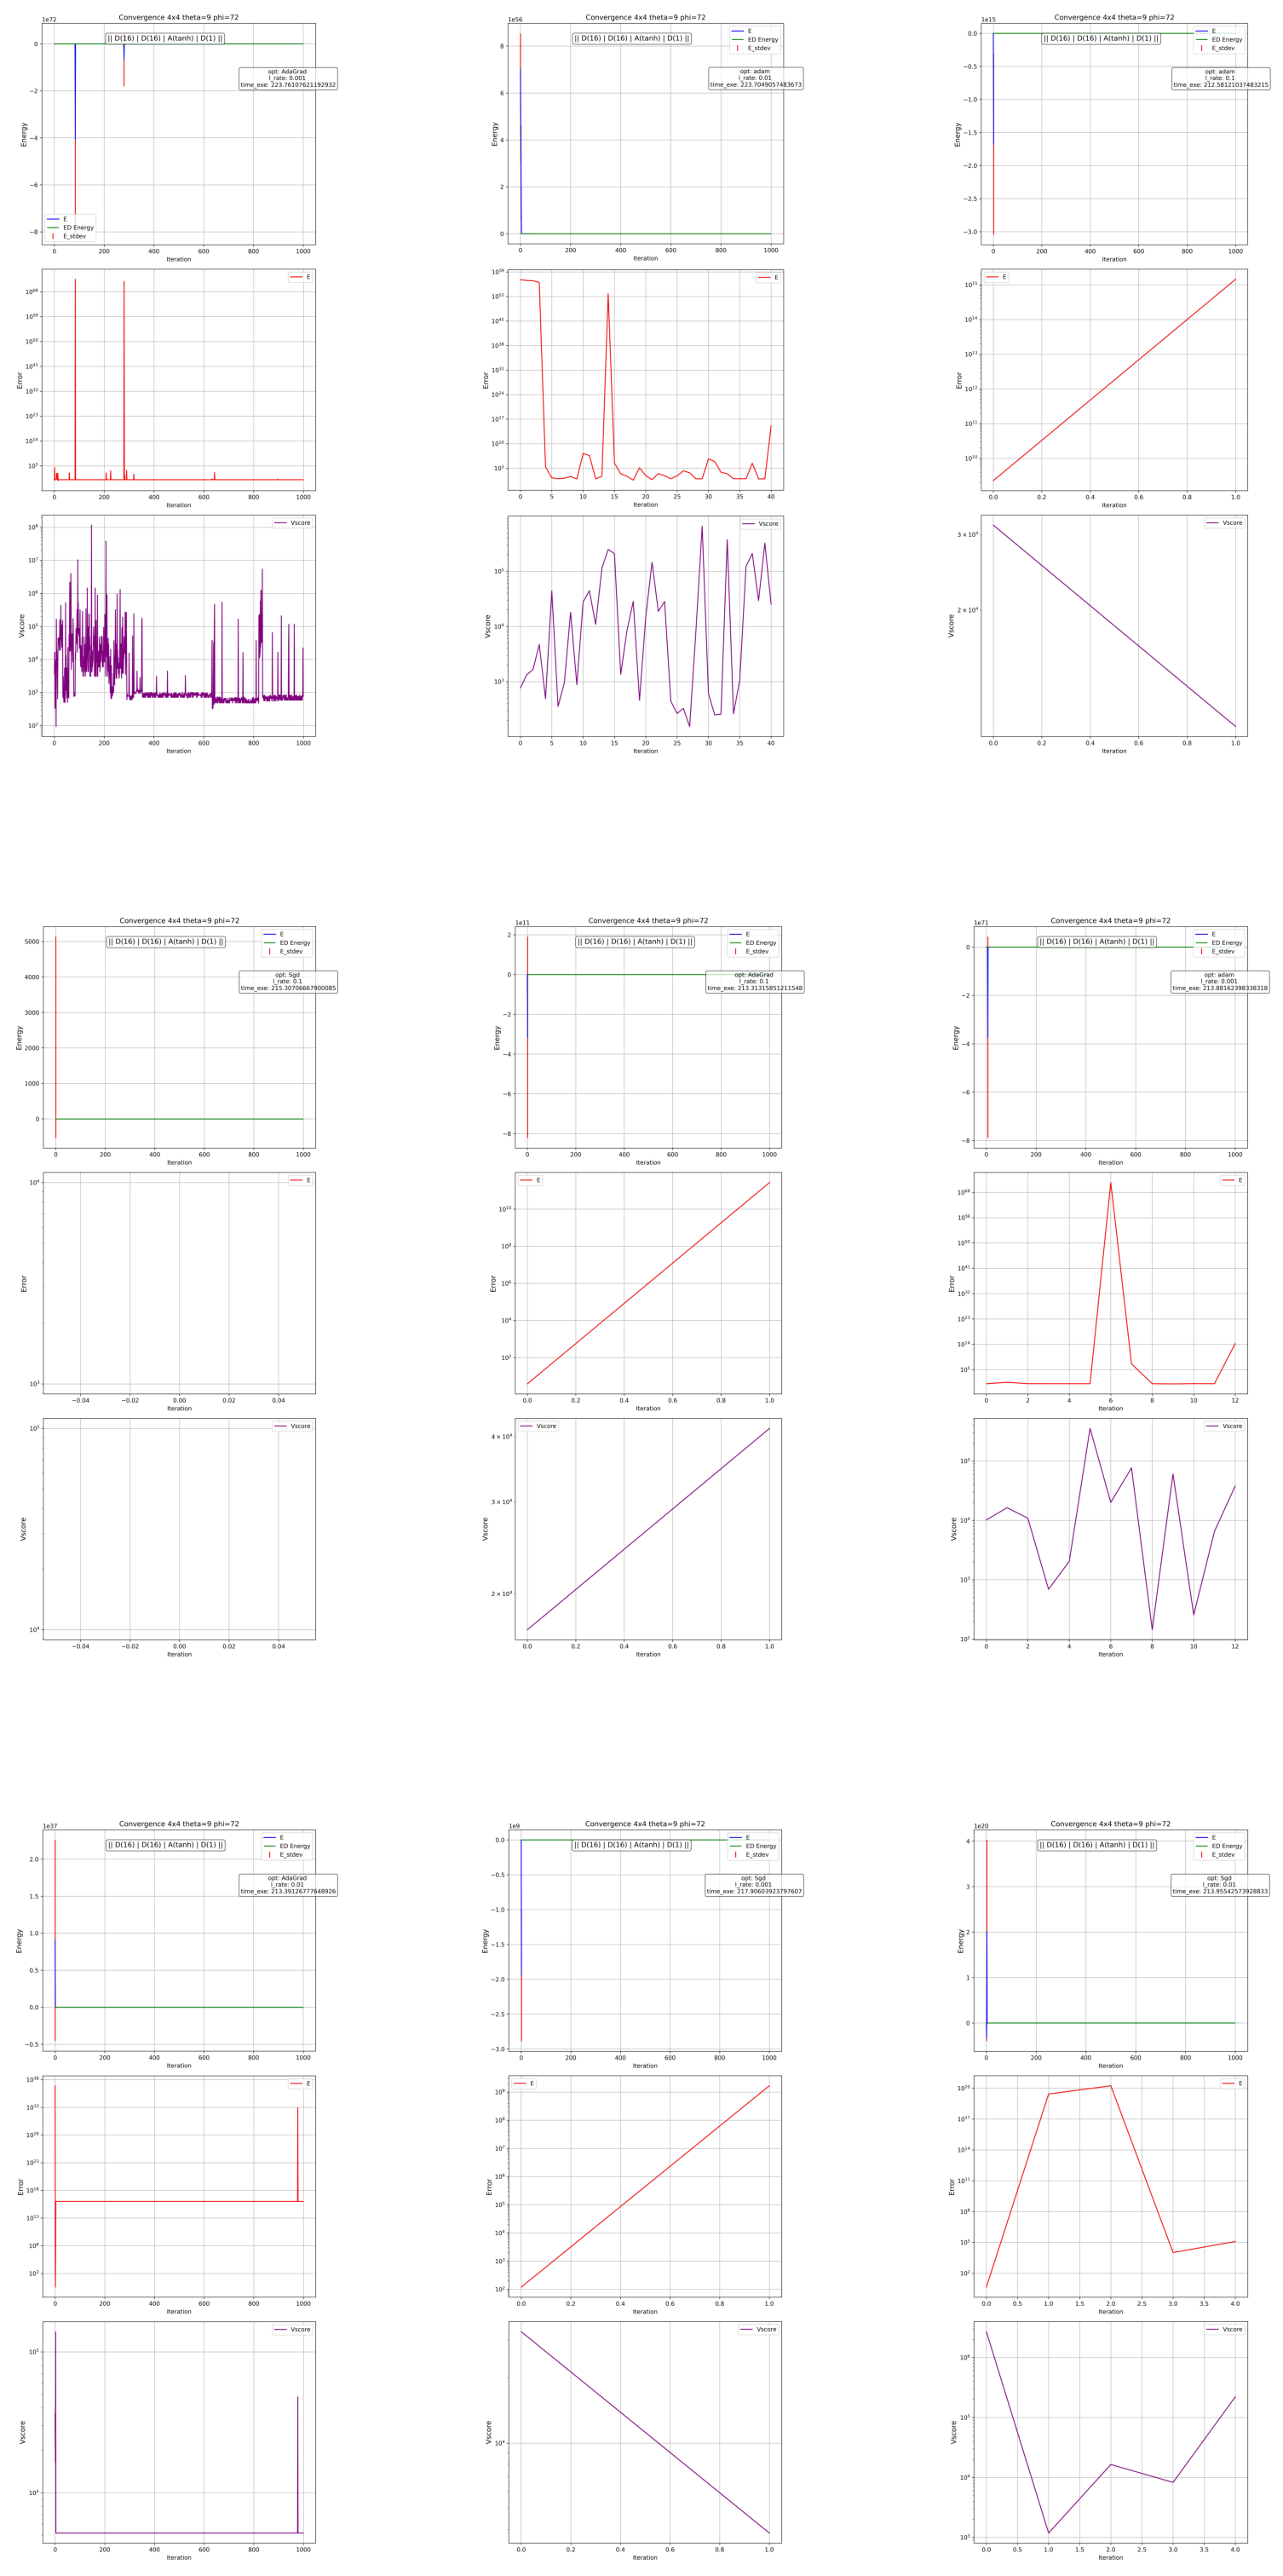

<Figure size 640x480 with 0 Axes>

In [42]:
import glob
from PIL import Image
folder = "/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/"

d=0
a=1
opt_name = 'Sgd'
learning_rate = 0.01

dim=f"*d{d}"
act=f"*a{a}"
opt=f"*{opt_name}"
lr=f"*{learning_rate}"
all = f"*{dim}*{act}*{opt}*{lr}"

filtro = dim + act 
files = glob.glob(folder + filtro +'*')


rows = len(files)//3 + len(files) % 3
fig,ax=plt.subplots(rows,3, figsize=(20, 13*rows))
ax=ax.flatten()
for i, file in enumerate(files):
    print(file)

    
    img = Image.open(file)
    ax[i].imshow(img)
    ax[i].axis('off')

if len(files) % 3 == 1:
    ax[-1].axis('off')
    ax[-1].axis('off')
if len(files) % 3 == 2:
    ax[-1].axis('off')

plt.axis('off')
plt.show()
plt.tight_layout()